### Forecast using Holt Winters Exponential Smoothing

#### <font color=blue>Simple Exponential Smoothing / Simple Moving Average</font>
This is the simplest to forecast. $\hat{y}$ is equal to the most recent value in the dataset, and the forecast plot is simply a horizontal line extending from the most recent value.
#### <font color=blue>Double Exponential Smoothing / Holt's Method</font>
This model takes trend into account. Here the forecast plot is still a straight line extending from the most recent value, but it has slope.
#### <font color=blue>Triple Exponential Smoothing / Holt-Winters Method</font>
This model has (so far) the "best" looking forecast plot, as it takes seasonality into account. When we expect regular fluctuations in the future, this model attempts to map the seasonal behavior.

#### 1) Importing Necessary Libraires:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.holtwinters import ExponentialSmoothing

from sklearn.metrics import mean_absolute_error, mean_squared_error

#### 2) Loading Data:

In [2]:
df = pd.read_csv('airline_passengers.csv', index_col= 0, parse_dates= True)

In [3]:
df.head()

,Thousands of Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [4]:
df.shape

(144, 1)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 1 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Thousands of Passengers  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB


In [6]:
df.describe()

,Thousands of Passengers
count,144.000000
mean,280.298611
std,119.966317
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000


##### Adding Frequency to Index:

In [7]:
df.index

DatetimeIndex(['1949-01-01', '1949-02-01', '1949-03-01', '1949-04-01',
               '1949-05-01', '1949-06-01', '1949-07-01', '1949-08-01',
               '1949-09-01', '1949-10-01',
               ...
               '1960-03-01', '1960-04-01', '1960-05-01', '1960-06-01',
               '1960-07-01', '1960-08-01', '1960-09-01', '1960-10-01',
               '1960-11-01', '1960-12-01'],
              dtype='datetime64[ns]', name='Month', length=144, freq=None)

In [9]:
df.index.freq = 'MS'

In [10]:
df.index

DatetimeIndex(['1949-01-01', '1949-02-01', '1949-03-01', '1949-04-01',
               '1949-05-01', '1949-06-01', '1949-07-01', '1949-08-01',
               '1949-09-01', '1949-10-01',
               ...
               '1960-03-01', '1960-04-01', '1960-05-01', '1960-06-01',
               '1960-07-01', '1960-08-01', '1960-09-01', '1960-10-01',
               '1960-11-01', '1960-12-01'],
              dtype='datetime64[ns]', name='Month', length=144, freq='MS')

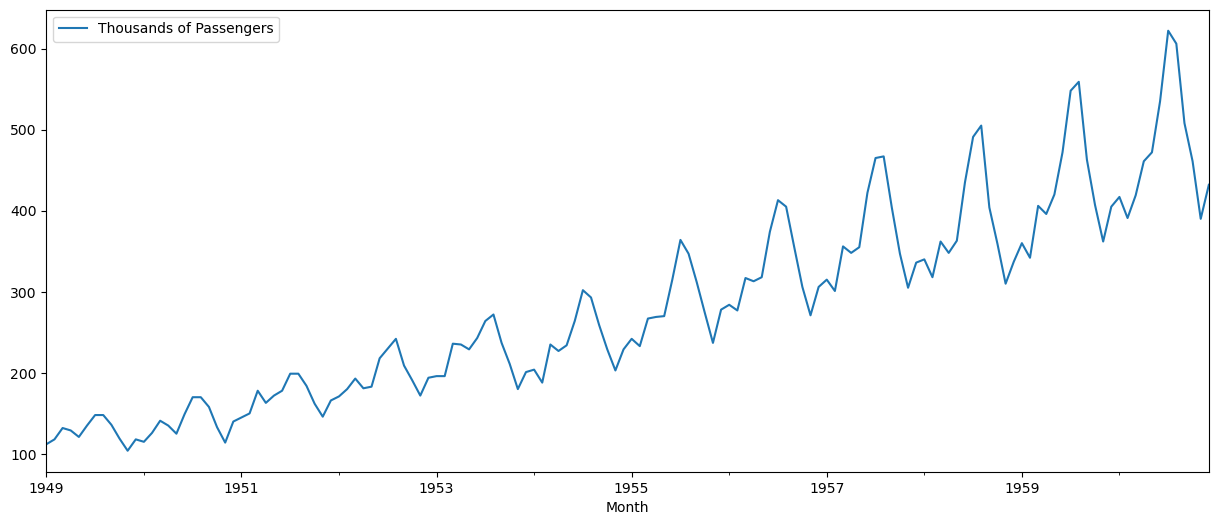

In [11]:
# Plotting Data:

df.plot(kind= 'line', figsize= (15,6))
plt.show()

#### 2) Train Test Split:

In [12]:
df

,Thousands of Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


In [13]:
train_data = df[:108]
test_data = df[108:]
print(train_data.shape, test_data.shape)

(108, 1) (36, 1)


#### 3) Multiplicative Model:

##### Model Fitting:

In [14]:
hw_model = ExponentialSmoothing(endog= train_data['Thousands of Passengers'],
                               trend= 'mul',
                               seasonal= 'mul',
                               seasonal_periods= 12).fit()

In [15]:
hw_model.fittedvalues

Month
1949-01-01    110.830241
1949-02-01    118.619749
1949-03-01    134.923663
1949-04-01    130.006189
1949-05-01    124.487166
                 ...    
1957-08-01    449.807529
1957-09-01    400.414443
1957-10-01    349.858045
1957-11-01    307.683639
1957-12-01    350.356113
Freq: MS, Length: 108, dtype: float64

##### Predictions on Test Data:

In [17]:
test_data.shape

(36, 1)

In [18]:
preds = hw_model.forecast(steps= 36)

In [20]:
preds.head()

1958-01-01    356.969191
1958-02-01    344.589121
1958-03-01    405.717960
1958-04-01    400.609637
1958-05-01    408.999635
Freq: MS, dtype: float64

In [21]:
preds.shape

(36,)

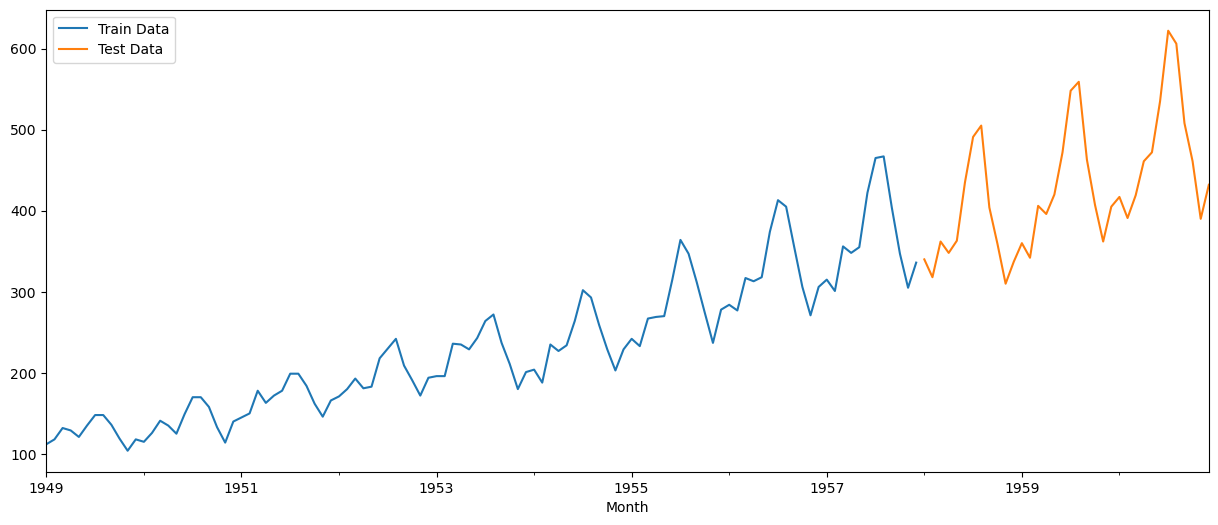

In [24]:
# Plotting Train and Test Data:

train_data['Thousands of Passengers'].plot(kind= 'line', figsize= (15,6), label= 'Train Data', legend= True)
test_data['Thousands of Passengers'].plot(kind= 'line', figsize= (15,6), label= 'Test Data', legend= True)
plt.show()

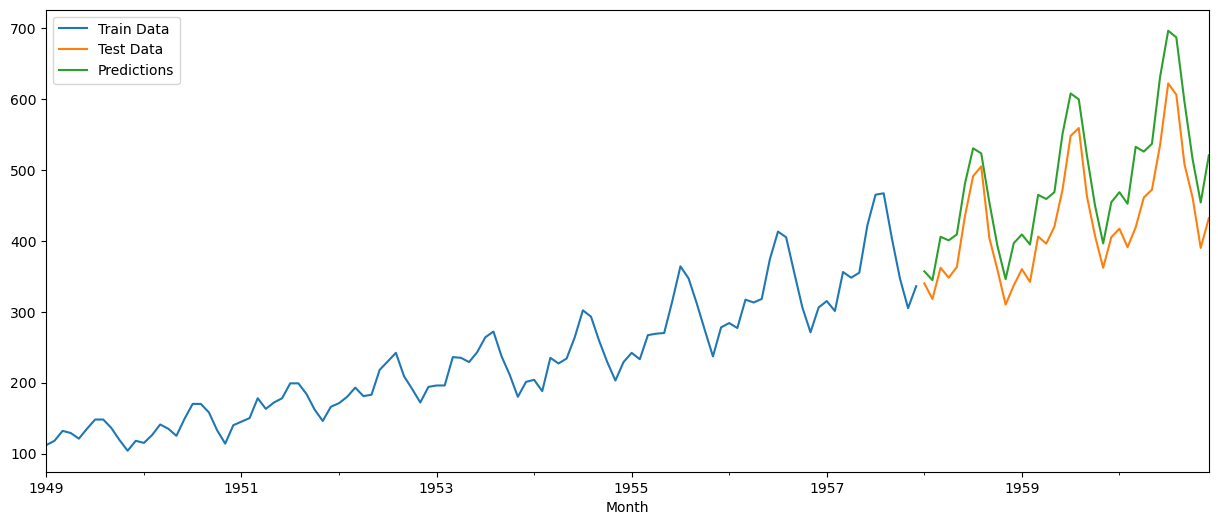

In [25]:
# Plotting Train Data, Test Data and Predictions for Test Data:

train_data['Thousands of Passengers'].plot(kind= 'line', figsize= (15,6), label= 'Train Data', legend= True)
test_data['Thousands of Passengers'].plot(kind= 'line', figsize= (15,6), label= 'Test Data', legend= True)
preds.plot(kind= 'line', figsize= (15,6), label= 'Predictions', legend= True)
plt.show()

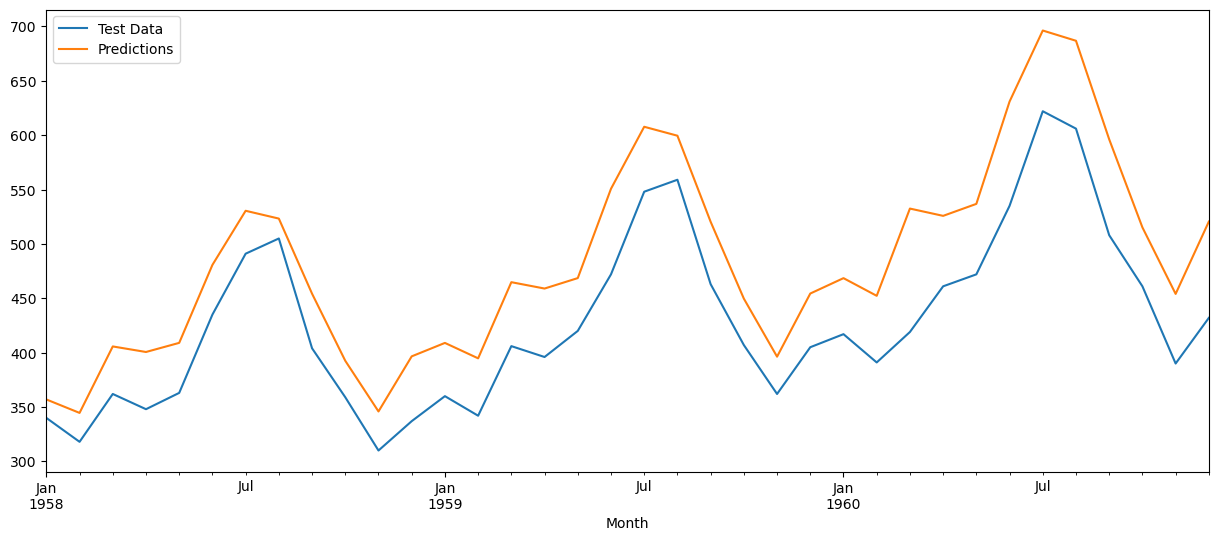

In [26]:
# Comparing Test Data and Predictions on Test Data:

test_data['Thousands of Passengers'].plot(kind= 'line', figsize= (15,6), label= 'Test Data', legend= True)
preds.plot(kind= 'line', figsize= (15,6), label= 'Predictions', legend= True)
plt.show()

##### Model Evaluation:

In [27]:
print(f'MAE: {mean_absolute_error(test_data, preds)}')
print(f'RMSE: {np.sqrt(mean_squared_error(test_data, preds))}')

MAE: 55.694663068445905
RMSE: 59.37534642148616


##### Forecasting:

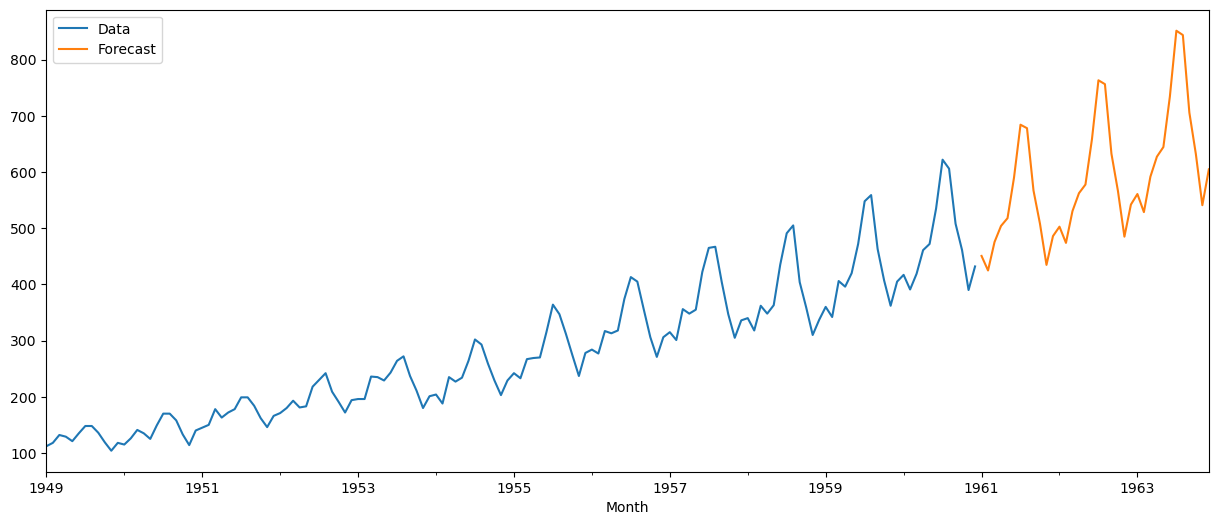

In [28]:
# Fitting Model on Full Data:
hw_model = ExponentialSmoothing(endog= df['Thousands of Passengers'],
                               trend= 'mul',
                               seasonal= 'mul',
                               seasonal_periods= 12).fit()

# Forecasting:
forecast = hw_model.forecast(steps= 36)

# Plotting Data and Forecast:
df['Thousands of Passengers'].plot(kind= 'line', figsize= (15,6), label= 'Data', legend= True)
forecast.plot(kind= 'line', figsize= (15,6), label= 'Forecast', legend= True)
plt.show()

#### 4) Additive Model:

##### Model Fitting:

In [29]:
hw_model = ExponentialSmoothing(endog= train_data['Thousands of Passengers'],
                               trend= 'add',
                               seasonal= 'add',
                               seasonal_periods= 12).fit()

In [30]:
hw_model.fittedvalues

Month
1949-01-01    111.998658
1949-02-01    120.057279
1949-03-01    134.511099
1949-04-01    131.150882
1949-05-01    124.358511
                 ...    
1957-08-01    437.790420
1957-09-01    394.438514
1957-10-01    350.059664
1957-11-01    316.166011
1957-12-01    350.879732
Freq: MS, Length: 108, dtype: float64

##### Predictions on Test Data:

In [31]:
test_data.shape

(36, 1)

In [32]:
preds = hw_model.forecast(steps= 36)

In [33]:
preds.head()

1958-01-01    357.332169
1958-02-01    345.819900
1958-03-01    398.634288
1958-04-01    390.191677
1958-05-01    396.346033
Freq: MS, dtype: float64

In [34]:
preds.shape

(36,)

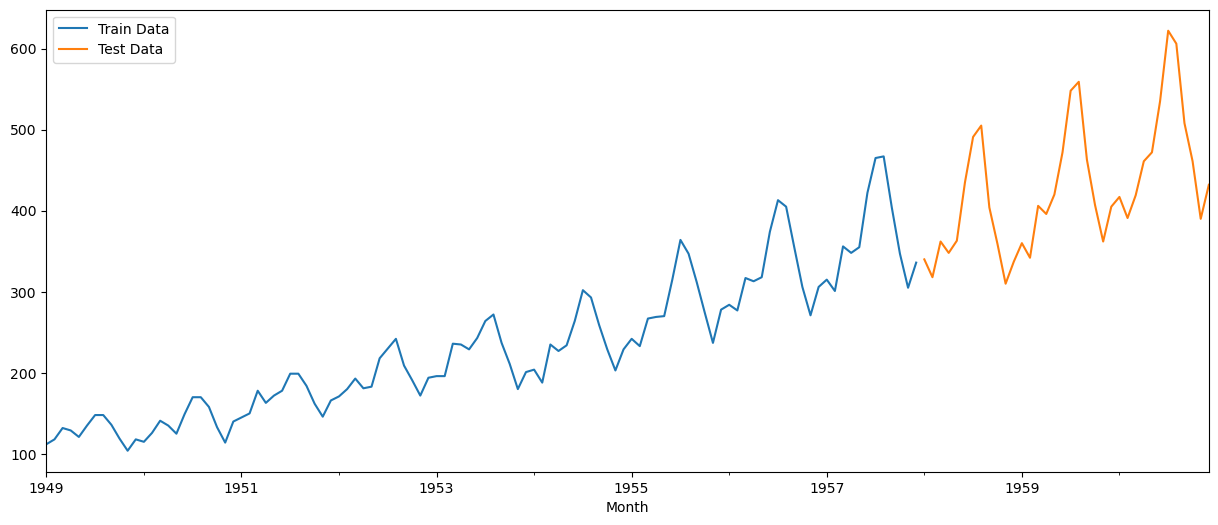

In [35]:
# Plotting Train and Test Data:

train_data['Thousands of Passengers'].plot(kind= 'line', figsize= (15,6), label= 'Train Data', legend= True)
test_data['Thousands of Passengers'].plot(kind= 'line', figsize= (15,6), label= 'Test Data', legend= True)
plt.show()

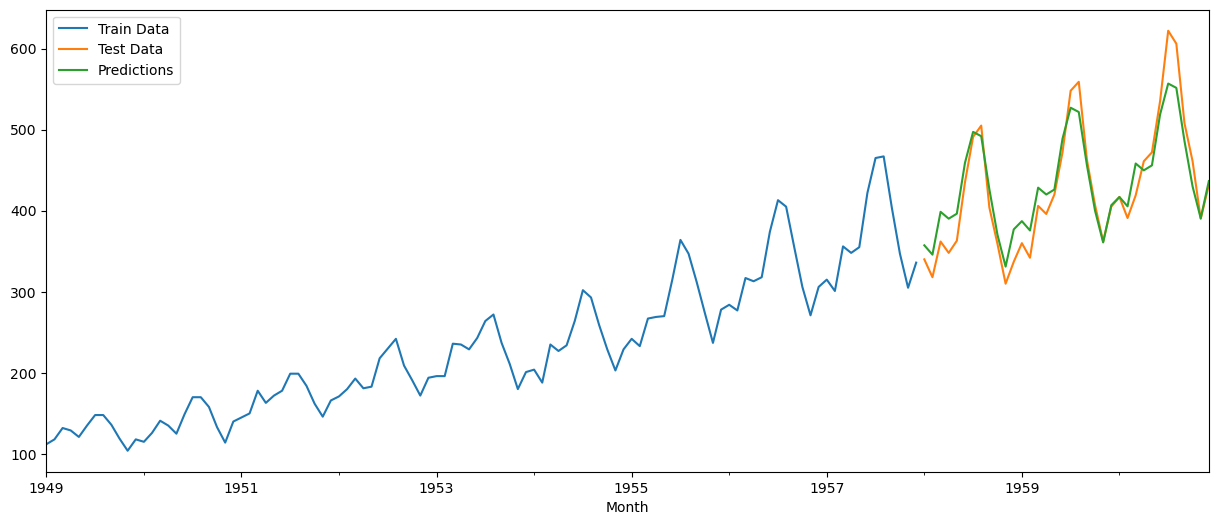

In [36]:
# Plotting Train Data, Test Data and Predictions for Test Data:

train_data['Thousands of Passengers'].plot(kind= 'line', figsize= (15,6), label= 'Train Data', legend= True)
test_data['Thousands of Passengers'].plot(kind= 'line', figsize= (15,6), label= 'Test Data', legend= True)
preds.plot(kind= 'line', figsize= (15,6), label= 'Predictions', legend= True)
plt.show()

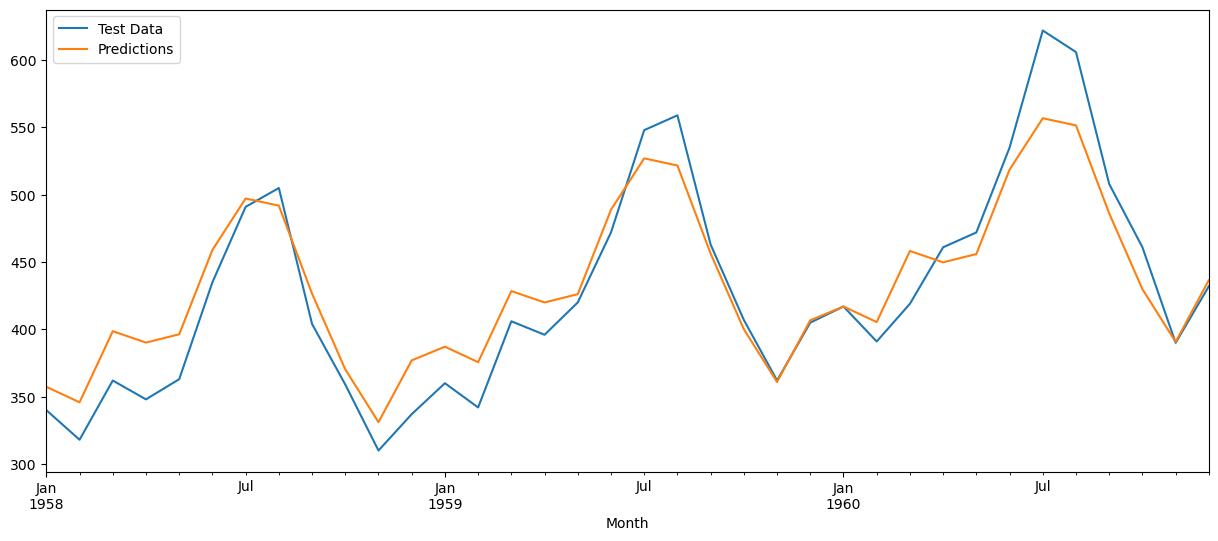

In [37]:
# Comparing Test Data and Predictions on Test Data:

test_data['Thousands of Passengers'].plot(kind= 'line', figsize= (15,6), label= 'Test Data', legend= True)
preds.plot(kind= 'line', figsize= (15,6), label= 'Predictions', legend= True)
plt.show()

##### Model Evaluation:

In [38]:
print(f'MAE: {mean_absolute_error(test_data, preds)}')
print(f'RMSE: {np.sqrt(mean_squared_error(test_data, preds))}')

MAE: 21.5447528235962
RMSE: 26.37573008195855


##### Forecasting:

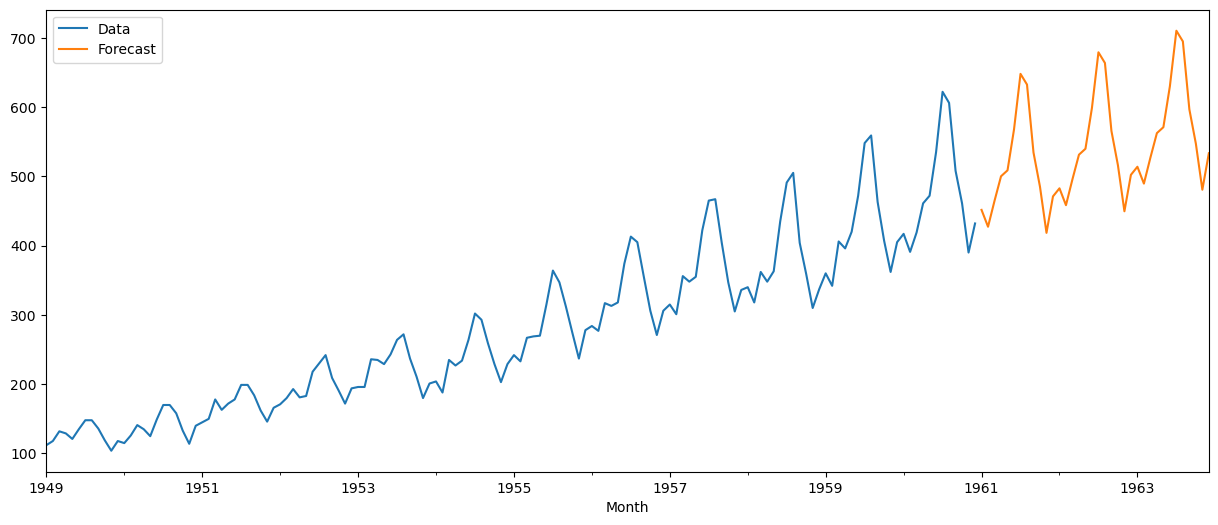

In [39]:
# Fitting Model on Full Data:
hw_model = ExponentialSmoothing(endog= df['Thousands of Passengers'],
                               trend= 'add',
                               seasonal= 'add',
                               seasonal_periods= 12).fit()

# Forecasting:
forecast = hw_model.forecast(steps= 36)

# Plotting Data and Forecast:
df['Thousands of Passengers'].plot(kind= 'line', figsize= (15,6), label= 'Data', legend= True)
forecast.plot(kind= 'line', figsize= (15,6), label= 'Forecast', legend= True)
plt.show()